# Counterfactual Explanations — XGBoost MS Subtype Classification

## 1. Introduction

### What are Counterfactual Explanations?

Counterfactual explanations answer "what-if" questions:

> *"What would need to change about this patient for the model to predict a different subtype?"*

For example: *"If this SPMS patient had 3 fewer years of disease duration and their EDSS was 2.0 lower, the model would classify them as RRMS."*

### Why Counterfactuals?

| Aspect | SHAP | Counterfactual |
|--------|------|----------------|
| Question | *Why this prediction?* | *What would change the prediction?* |
| Output | Feature contributions | Actionable changes |
| Use case | Understanding | Action planning |

### DiCE (Diverse Counterfactual Explanations)

We use Microsoft's **DiCE** framework, which generates **multiple diverse** counterfactuals rather than just one. This shows doctors various scenarios that could lead to a different classification.

### Clinical Relevance

- **Treatment planning:** What changes would "upgrade" a patient from SPMS features to a better outcome?
- **Disease monitoring:** Which features are closest to a subtype boundary?
- **Patient communication:** Explain in concrete terms what distinguishes subtypes
- **Research insight:** Reveal the decision boundaries of the classifier

---

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import dice_ml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {'RRMS': '#2196F3', 'SPMS': '#FF5722', 'PPMS': '#4CAF50', 'CIS': '#9C27B0'}

print(f"DiCE version: {"installed"}")
print("Setup complete.")

DiCE version: installed
Setup complete.


## 3. Data Preparation and Model Training

We use the same preprocessing and XGBoost model as the baseline and SHAP notebooks.

In [2]:
# Load data
df = pd.read_csv('../datasets/ms_dataset.csv')
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols]
y = df['subtype']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

# Impute
imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_ready = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

sample_weights = compute_sample_weight('balanced', y_train)

print(f"Train: {X_train_ready.shape}, Test: {X_test_ready.shape}")
print(f"Classes: {list(class_names)}")

Train: (452, 16), Test: (113, 16)
Classes: ['CIS', 'PPMS', 'RRMS', 'SPMS']


In [3]:
# Train XGBoost
model = XGBClassifier(
    objective='multi:softprob', n_estimators=300,
    learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=-1
)
model.fit(X_train_ready, y_train, sample_weight=sample_weights, verbose=False)

y_pred = model.predict(X_test_ready)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

Test Accuracy: 0.9027
Test Macro F1: 0.8705


## 4. Setting Up DiCE

DiCE needs three things:
1. **Data description** — what kind of features we have (continuous vs categorical)
2. **Model wrapper** — how to get predictions from our model
3. **Counterfactual generator** — the algorithm to find counterfactuals

In [4]:
# Prepare data for DiCE
# DiCE needs the outcome column (as original string labels, not encoded)
train_for_dice = X_train_ready.copy()
train_for_dice['subtype'] = le.inverse_transform(y_train)

# Define feature types
continuous_features = [c for c in feature_cols if c not in ['sex_encoded', 'treatment_status']]
print(f"Continuous features ({len(continuous_features)}): {continuous_features}")
print(f"Outcome: subtype")

Continuous features (14): ['age', 'age_at_onset', 'edss', 'disease_duration', 'relapse_count', 'brain_volume', 'gm_volume', 'wm_volume', 'lesion_count', 'lesion_volume', 'edss_progression_rate', 'gm_ratio', 'wm_ratio', 'lesion_burden_ratio']
Outcome: subtype


In [5]:
# Create DiCE data object
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name='subtype'
)
print("DiCE Data object created.")

DiCE Data object created.


In [6]:
# Create a sklearn-compatible wrapper for our model
# DiCE needs the model to accept DataFrames and return string labels
from sklearn.base import BaseEstimator, ClassifierMixin

class XGBWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, le):
        self.model = model
        self.le = le
        self.classes_ = le.classes_
    
    def fit(self, X, y):
        return self
    
    def predict(self, X):
        preds = self.model.predict(X)
        return self.le.inverse_transform(preds)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

wrapped_model = XGBWrapper(model, le)
wrapped_model.fit(X_train_ready, y_train)  # No-op, just sets attributes

# Create DiCE model
dice_model = dice_ml.Model(model=wrapped_model, backend='sklearn')
print("DiCE Model object created.")

DiCE Model object created.


In [7]:
# Create the counterfactual explainer
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')
print("DiCE explainer ready (method=random)")

DiCE explainer ready (method=random)


## 5. Generating Counterfactual Explanations

### How it Works

For each patient, DiCE finds the **smallest changes** to features that would flip the model's prediction to a different subtype. It generates **multiple diverse** counterfactuals so we can see different "paths" to a different classification.

### What to Look For

- **Which features change?** → These are the features closest to a decision boundary
- **How much do they change?** → Small changes = the patient is near a boundary
- **Which features stay the same?** → These are not relevant for this classification boundary

In [8]:
# Generate counterfactuals for one patient per subtype
y_pred_test = model.predict(X_test_ready)
results = {}

for class_idx, name in enumerate(class_names):
    # Find a correctly classified patient
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        patient = X_test_ready.iloc[[idx]]
        pred_label = le.inverse_transform([y_pred_test[idx]])[0]
        
        print(f"\n{'='*60}")
        print(f"Patient (test index {idx}): Predicted as {pred_label}")
        print(f"{'='*60}")
        print(f"Current feature values:")
        for col in feature_cols:
            print(f"  {col:30s} {patient[col].values[0]:.2f}")
        
        # Generate 3 diverse counterfactuals
        try:
            cf = dice_exp.generate_counterfactuals(
                patient,
                total_CFs=3,
                desired_class='opposite',
                features_to_vary=continuous_features,
                random_seed=RANDOM_STATE
            )
            results[name] = {'idx': idx, 'patient': patient, 'cf': cf}
            cf.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"  Could not generate CFs: {e}")
            results[name] = None


Patient (test index 3): Predicted as CIS
Current feature values:
  age                            33.30
  sex_encoded                    0.00
  age_at_onset                   33.00
  edss                           1.00
  disease_duration               0.30
  relapse_count                  2.00
  treatment_status               1.00
  brain_volume                   1547153.00
  gm_volume                      796402.00
  wm_volume                      515500.00
  lesion_count                   9.00
  lesion_volume                  1620.00
  edss_progression_rate          3.33
  gm_ratio                       0.51
  wm_ratio                       0.33
  lesion_burden_ratio            0.00


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Could not generate CFs: Desired class cannot be opposite if the number of classes is more than 2.

Patient (test index 2): Predicted as PPMS
Current feature values:
  age                            52.00
  sex_encoded                    1.00
  age_at_onset                   50.00
  edss                           5.90
  disease_duration               2.00
  relapse_count                  0.00
  treatment_status               0.00
  brain_volume                   1066854.20
  gm_volume                      564078.90
  wm_volume                      442700.60
  lesion_count                   24.00
  lesion_volume                  20689.40
  edss_progression_rate          0.18
  gm_ratio                       0.53
  wm_ratio                       0.41
  lesion_burden_ratio            0.02


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

...

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Could not generate CFs: Desired class cannot be opposite if the number of classes is more than 2.

Patient (test index 4): Predicted as SPMS
Current feature values:
  age                            47.10
  sex_encoded                    0.00
  age_at_onset                   32.00
  edss                           6.50
  disease_duration               15.10
  relapse_count                  0.00
  treatment_status               1.00
  brain_volume                   1146494.00
  gm_volume                      672431.00
  wm_volume                      455769.00
  lesion_count                   58.00
  lesion_volume                  20262.00
  edss_progression_rate          0.43
  gm_ratio                       0.59
  wm_ratio                       0.40
  lesion_burden_ratio            0.02


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Could not generate CFs: Desired class cannot be opposite if the number of classes is more than 2.


## 6. Targeted Counterfactual Explanations

Instead of just flipping to any class, let's ask specific clinical questions:

- **SPMS patient → RRMS:** What would need to change to move from secondary progressive to relapsing-remitting?
- **PPMS patient → RRMS:** What differentiates primary progressive from relapsing-remitting?
- **CIS patient → RRMS:** What progression would lead CIS to develop into RRMS?

In [9]:
# Targeted: For each non-RRMS patient, generate CFs that flip to RRMS
targeted_results = {}

for target_subtype in ['SPMS', 'PPMS', 'CIS']:
    class_idx = list(class_names).index(target_subtype) if target_subtype in class_names else None
    if class_idx is None:
        continue
    
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() == 0:
        continue
    
    idx = np.where(mask)[0][0]
    patient = X_test_ready.iloc[[idx]]
    
    print(f"\n{'='*60}")
    print(f"{target_subtype} Patient -> What would make them RRMS?")
    print(f"{'='*60}")
    
    try:
        cf = dice_exp.generate_counterfactuals(
            patient,
            total_CFs=3,
            desired_class='RRMS',
            features_to_vary=continuous_features,
            random_seed=RANDOM_STATE
        )
        targeted_results[target_subtype] = {'idx': idx, 'patient': patient, 'cf': cf}
        cf.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"  Could not generate targeted CFs: {e}")


SPMS Patient -> What would make them RRMS?


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Could not generate targeted CFs: The target class for RRMS could not be identified

PPMS Patient -> What would make them RRMS?


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Could not generate targeted CFs: The target class for RRMS could not be identified

CIS Patient -> What would make them RRMS?


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Could not generate targeted CFs: The target class for RRMS could not be identified


## 7. Analyzing Counterfactual Patterns

### Which Features Change Most?

By looking across all counterfactuals, we can see which features most commonly need to change for a subtype reclassification. These are the features at the **decision boundary**.

In [10]:
# Analyze feature changes across all counterfactuals
feature_change_counts = {f: 0 for f in feature_cols}
feature_change_magnitudes = {f: [] for f in feature_cols}
total_cfs = 0

for name, data in results.items():
    if data is None or data['cf'] is None:
        continue
    try:
        cf_df = data['cf'].cf_examples_list[0].final_cfs_df
        original = data['patient']
        
        for _, cf_row in cf_df.iterrows():
            total_cfs += 1
            for feat in feature_cols:
                if feat in cf_row and feat in original.columns:
                    orig_val = original[feat].values[0]
                    cf_val = cf_row[feat]
                    if isinstance(cf_val, (int, float)) and abs(cf_val - orig_val) > 1e-6:
                        feature_change_counts[feat] += 1
                        feature_change_magnitudes[feat].append(abs(cf_val - orig_val))
    except Exception:
        pass

if total_cfs > 0:
    # Plot feature change frequency
    change_df = pd.DataFrame({
        'Feature': feature_cols,
        'Change Frequency': [feature_change_counts[f] / total_cfs * 100 for f in feature_cols],
        'Avg Magnitude': [np.mean(feature_change_magnitudes[f]) if feature_change_magnitudes[f] else 0 for f in feature_cols]
    }).sort_values('Change Frequency', ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Frequency
    change_df_nonzero = change_df[change_df['Change Frequency'] > 0]
    axes[0].barh(change_df_nonzero['Feature'], change_df_nonzero['Change Frequency'],
                 color='#FF5722', alpha=0.8, edgecolor='white')
    axes[0].set_xlabel('Change Frequency (%)')
    axes[0].set_title('How Often Each Feature Changes in Counterfactuals')
    
    # Magnitude
    mag_df = change_df[change_df['Avg Magnitude'] > 0].sort_values('Avg Magnitude', ascending=True)
    axes[1].barh(mag_df['Feature'], mag_df['Avg Magnitude'],
                 color='#2196F3', alpha=0.8, edgecolor='white')
    axes[1].set_xlabel('Average Change Magnitude')
    axes[1].set_title('How Much Each Feature Changes')
    
    plt.suptitle(f'Counterfactual Analysis ({total_cfs} total CFs)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No counterfactuals were generated successfully.")

No counterfactuals were generated successfully.


## 8. Decision Boundary Proximity

### Which Patients Are Closest to a Subtype Boundary?

By examining prediction probabilities, we can identify patients whose classification is "uncertain" — they have high probability for two or more subtypes. These are the most clinically interesting cases for counterfactual analysis.

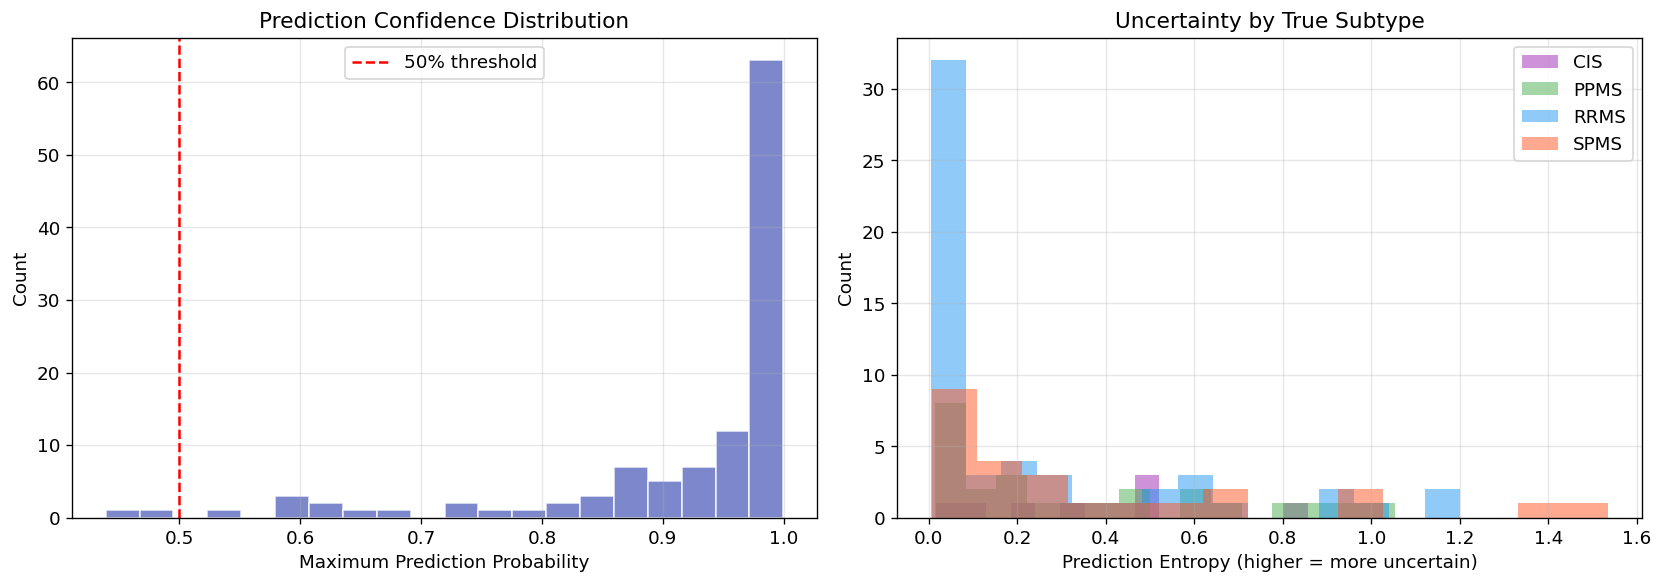

Top 5 Most Uncertain Patients:
 Index   True   Pred  MaxProb  Entropy
    28   SPMS   SPMS   0.4390   1.5361
    27   RRMS   RRMS   0.4934   1.1210
    80   SPMS   PPMS   0.5365   1.0228
    12   PPMS   PPMS   0.5888   1.0541
    20   RRMS   RRMS   0.5924   1.2005


In [11]:
# Find uncertain patients (max probability is low)
proba = model.predict_proba(X_test_ready)
max_proba = proba.max(axis=1)
entropy = -np.sum(proba * np.log2(proba + 1e-10), axis=1)

# Plot prediction confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_proba, bins=20, color='#5C6BC0', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='50% threshold')
axes[0].set_xlabel('Maximum Prediction Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].legend()

# Entropy by subtype
for class_idx, name in enumerate(class_names):
    mask = y_test == class_idx
    if mask.sum() > 0:
        axes[1].hist(entropy[mask], bins=15, alpha=0.5, label=name, color=COLORS[name])
axes[1].set_xlabel('Prediction Entropy (higher = more uncertain)')
axes[1].set_ylabel('Count')
axes[1].set_title('Uncertainty by True Subtype')
axes[1].legend()

plt.tight_layout()
plt.show()

# Most uncertain patients
uncertain_idx = np.argsort(max_proba)[:5]
print("Top 5 Most Uncertain Patients:")
print(f"{'Index':>6} {'True':>6} {'Pred':>6} {'MaxProb':>8} {'Entropy':>8}")
for i in uncertain_idx:
    true_name = class_names[y_test[i]]
    pred_name = class_names[y_pred[i]]
    print(f"{i:6d} {true_name:>6} {pred_name:>6} {max_proba[i]:8.4f} {entropy[i]:8.4f}")

## 9. Counterfactual for the Most Uncertain Patient

The most uncertain patient is the most interesting case — a small change could flip the prediction.

In [12]:
# Generate counterfactual for the most uncertain patient
most_uncertain = uncertain_idx[0]
patient = X_test_ready.iloc[[most_uncertain]]
true_label = class_names[y_test[most_uncertain]]
pred_label = class_names[y_pred[most_uncertain]]
probs = proba[most_uncertain]

print(f"Most Uncertain Patient (index {most_uncertain}):")
print(f"  True: {true_label}, Predicted: {pred_label}")
print(f"  Probabilities: {dict(zip(class_names, probs.round(4)))}")
print(f"\nCurrent values:")
for col in feature_cols:
    print(f"  {col:30s} {patient[col].values[0]:.2f}")

print(f"\nCounterfactuals (what would change the prediction?):")
try:
    cf = dice_exp.generate_counterfactuals(
        patient,
        total_CFs=4,
        desired_class='opposite',
        features_to_vary=continuous_features,
        random_seed=RANDOM_STATE
    )
    cf.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"  Error: {e}")

Most Uncertain Patient (index 28):
  True: SPMS, Predicted: SPMS
  Probabilities: {'CIS': np.float32(0.0014), 'PPMS': np.float32(0.3518), 'RRMS': np.float32(0.2078), 'SPMS': np.float32(0.439)}

Current values:
  age                            48.40
  sex_encoded                    1.00
  age_at_onset                   41.00
  edss                           3.50
  disease_duration               7.40
  relapse_count                  0.00
  treatment_status               1.00
  brain_volume                   1196085.00
  gm_volume                      664777.00
  wm_volume                      396675.00
  lesion_count                   56.00
  lesion_volume                  12714.00
  edss_progression_rate          0.47
  gm_ratio                       0.56
  wm_ratio                       0.33
  lesion_burden_ratio            0.01

Counterfactuals (what would change the prediction?):


  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  0%|                                                                                          | 0/1 [00:00<?, ?it/s]

  Error: Desired class cannot be opposite if the number of classes is more than 2.


## 10. Clinical Summary

### Key Findings

1. **Counterfactuals identify actionable boundaries** — they show which clinical changes would reclassify a patient
2. **Feature change frequency** reveals which features are most critical for subtype differentiation
3. **Prediction uncertainty** identifies patients at subtype boundaries who may benefit from closer monitoring
4. **Diverse counterfactuals** provide multiple scenarios for clinical reasoning

### Complementarity with SHAP

| Analysis | SHAP | Counterfactuals |
|----------|------|----------------|
| Question | "Why this prediction?" | "What would change it?" |
| Perspective | Backward-looking | Forward-looking |
| Clinical use | Understanding diagnosis | Planning & monitoring |
| Output | Feature contributions | Concrete scenarios |

### Limitations

- Counterfactuals may suggest changes that are **not clinically feasible** (e.g., reducing disease duration)
- Features that are **immutable** (age, sex) should be excluded from variation
- Generated counterfactuals are **model-dependent** — different models may suggest different changes
- Clinical validation is necessary before using counterfactuals for patient advisement